# Spectral Analysis

This notebook demonstrates the spectral-analysis functions in `pygc.spectral_analysis`; the multitaper and Morlet routines wrap MNE, while the Fourier and Welch routines wrap NumPy/SciPy.

1. **Synthetic Signal** — Generate synthetic data for the examples
2. **Fourier cross-spectrum** — Auto- and cross-spectra via Fourier (for stationary signals).
3. **Multitaper cross-spectrum** — Trial-averaged cross-spectral matrix
4. **Morlet wavelet transform** — Time-frequency representation
5. **Welch cross-spectrum** — Trial-averaged PSD / CSD

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pygc.spectral_analysis import (
    compute_freq,
    csd_fourier,
    morlet_transform,
    multitaper_spectrum,
    welch_spectrum,
)

plt.rcParams.update({"figure.dpi": 100, "font.size": 12})

## 1. Synthetic Signal

We generate two signals that share a common 30 Hz oscillation; `y` also contains a 10 Hz component.

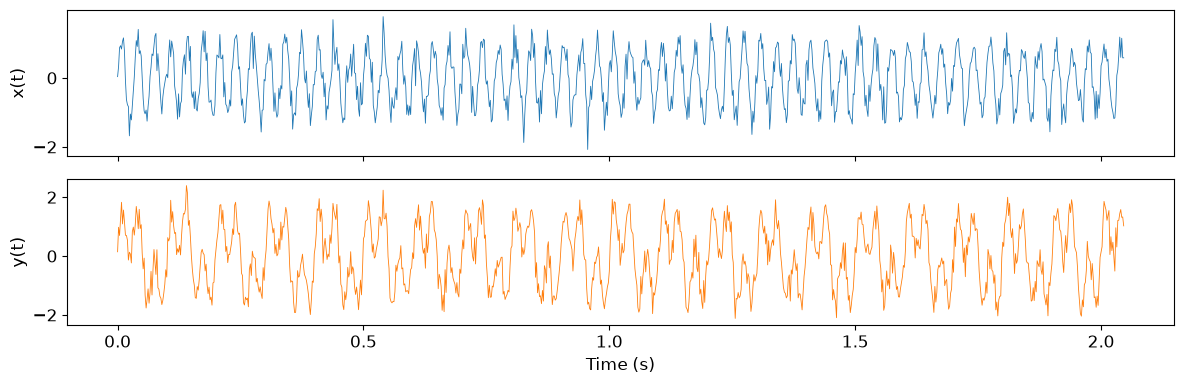

In [2]:
Fs = 500.0  # Hz
N = 1024  # samples
t = np.arange(N) / Fs

rng = np.random.default_rng(0)

# a single 30 Hz oscillation shared by both signals
shared_30hz = np.sin(2 * np.pi * 30 * t)

x = shared_30hz + 0.3 * rng.standard_normal(N)
y = shared_30hz + np.sin(2 * np.pi * 10 * t) + 0.3 * rng.standard_normal(N)

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(t, x, lw=0.6)
axes[0].set_ylabel("x(t)")
axes[1].plot(t, y, lw=0.6, color="C1")
axes[1].set_ylabel("y(t)")
axes[1].set_xlabel("Time (s)")
plt.tight_layout()


def make_trials(n_trials, seed):
    """Stack ``n_trials`` noisy realizations of ``(x, y)`` into ``(n_trials, 2, N)``."""
    gen = np.random.default_rng(seed)
    trials = [
        np.stack(
            [
                shared_30hz + 0.3 * gen.standard_normal(N),
                shared_30hz
                + np.sin(2 * np.pi * 10 * t)
                + 0.3 * gen.standard_normal(N),
            ],
            axis=0,
        )
        for _ in range(n_trials)
    ]
    return np.stack(trials, axis=0)

## 2. Fourier Cross-Spectrum

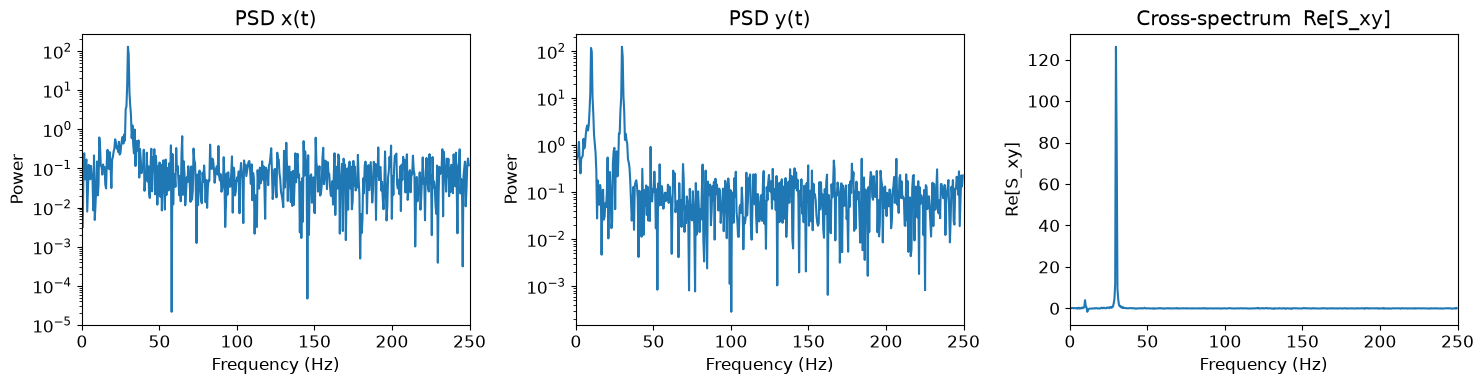

In [3]:
freq = compute_freq(N, Fs)

Pxx = csd_fourier(x, f=freq, Fs=Fs)  # auto-spectrum
Pyy = csd_fourier(y, f=freq, Fs=Fs)
Pxy = csd_fourier(x, Y=y, f=freq, Fs=Fs)  # cross-spectrum

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].semilogy(freq, Pxx.real)
axes[0].set_title("PSD x(t)")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Power")
axes[0].set_xlim([0, Fs / 2])

axes[1].semilogy(freq, Pyy.real)
axes[1].set_title("PSD y(t)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power")
axes[1].set_xlim([0, Fs / 2])

axes[2].plot(freq, Pxy.real)
axes[2].set_title("Cross-spectrum  Re[S_xy]")
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_ylabel("Re[S_xy]")
axes[2].set_xlim([0, Fs / 2])

plt.tight_layout()

## 3. Multitaper Cross-Spectrum (trial-averaged)

`multitaper_spectrum` computes the cross-spectral matrix averaged across trials using `mne.time_frequency.csd_array_multitaper`.

Data shape (trials, channels, samples): (10, 2, 1024)
Multitaper spectral matrix shape: (2, 2, 512)


/home/shimoura/Github/pyGC/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


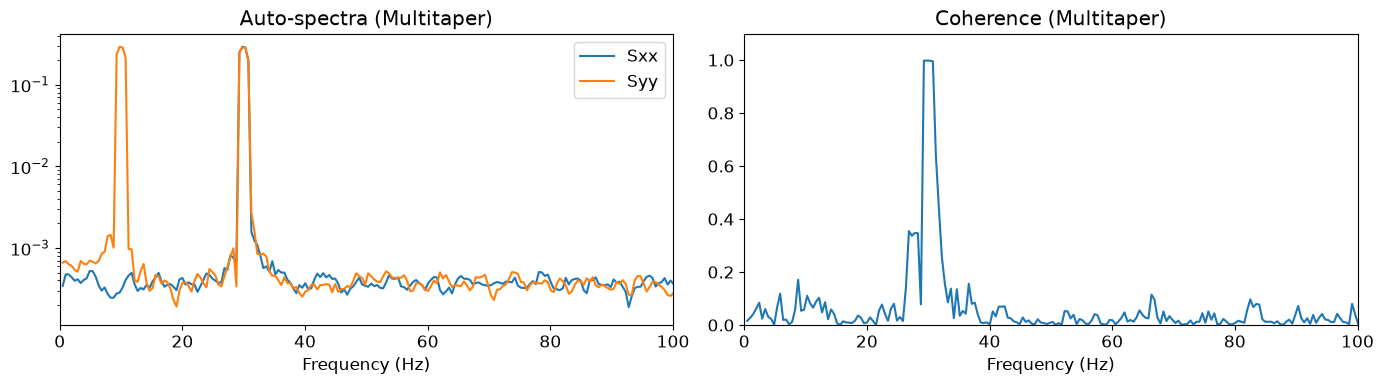

In [4]:
FMIN, FMAX = 0, 250

data = make_trials(n_trials=10, seed=0)
print("Data shape (trials, channels, samples):", data.shape)

S_mt, freqs_mt = multitaper_spectrum(data, Fs, bandwidth=2, fmin=FMIN, fmax=FMAX)
print("Multitaper spectral matrix shape:", S_mt.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].semilogy(freqs_mt, S_mt[0, 0, :].real, label="Sxx")
axes[0].semilogy(freqs_mt, S_mt[1, 1, :].real, label="Syy")
axes[0].set_title("Auto-spectra (Multitaper)")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].legend()
axes[0].set_xlim([0, 100])

coh_mt = np.abs(S_mt[0, 1, :]) ** 2 / (
    S_mt[0, 0, :].real * S_mt[1, 1, :].real
)
axes[1].plot(freqs_mt, coh_mt.real)
axes[1].set_title("Coherence (Multitaper)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylim([0, 1.1])
axes[1].set_xlim([0, 100])
plt.tight_layout()

## 4. Morlet Wavelet Transform (MNE)

`morlet_transform` uses `mne.time_frequency.tfr_array_morlet` internally.

Wavelet transform shape (time x freq): (1024, 35)


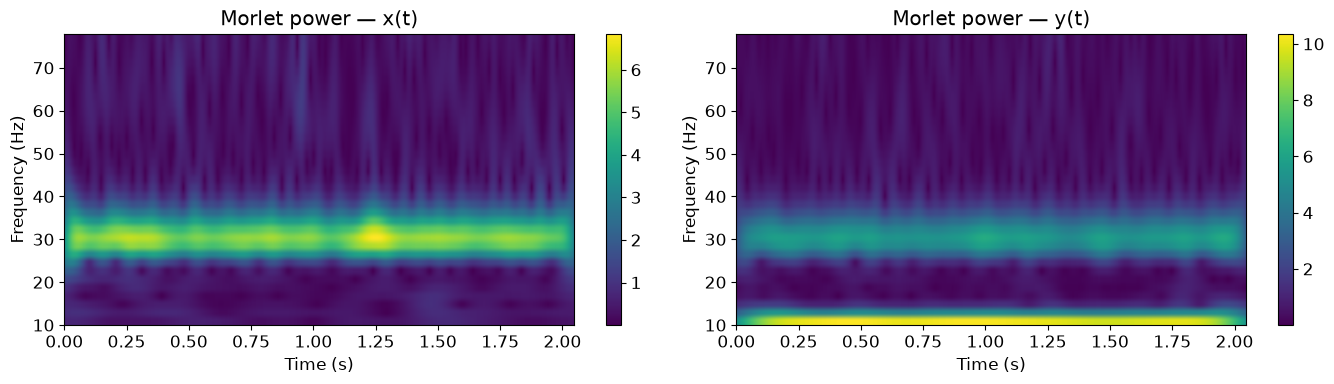

In [5]:
freqs_wav = np.arange(10, 80, 2, dtype=float)

Wx = morlet_transform(x, freqs_wav, Fs=Fs, n_cycles=7.0)
Wy = morlet_transform(y, freqs_wav, Fs=Fs, n_cycles=7.0)

print("Wavelet transform shape (time x freq):", Wx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, W, label in zip(axes, [Wx, Wy], ["x(t)", "y(t)"]):
    im = ax.imshow(
        np.abs(W).T,
        aspect="auto",
        origin="lower",
        extent=[0, N / Fs, freqs_wav[0], freqs_wav[-1]],
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(f"Morlet power — {label}")
    plt.colorbar(im, ax=ax)
plt.tight_layout()

## 5. Welch Cross-Spectrum (trial-averaged)

`welch_spectrum` computes the cross-spectral matrix averaged across trials using `scipy.signal.csd`.

Data shape (trials, channels, samples): (10, 2, 1024)
Welch spectral matrix shape: (2, 2, 129)


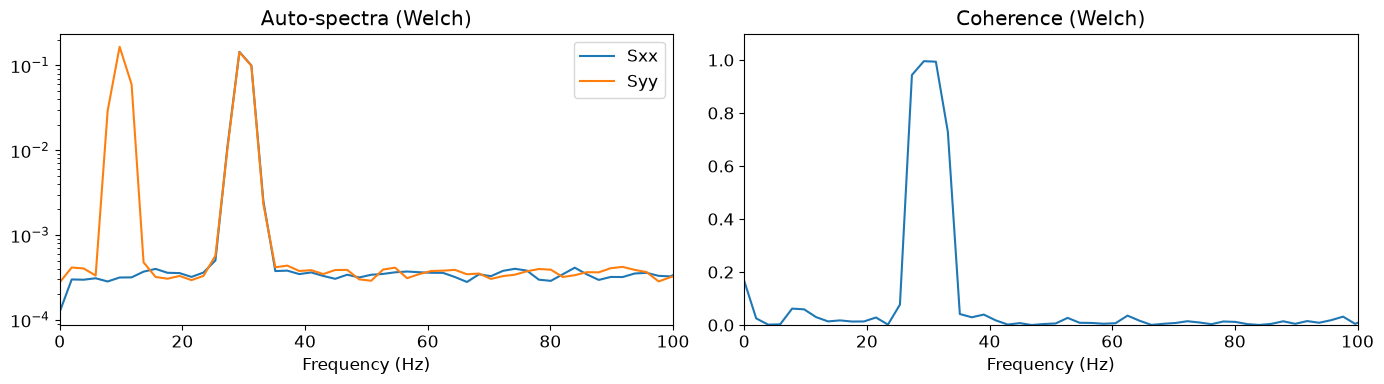

In [6]:
data = make_trials(n_trials=10, seed=1)
print("Data shape (trials, channels, samples):", data.shape)

S_welch = welch_spectrum(data=data, fs=Fs, scaling="density")
print("Welch spectral matrix shape:", S_welch.shape)

n_freq_welch = S_welch.shape[-1]
f_welch = np.linspace(0, Fs / 2, n_freq_welch)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].semilogy(f_welch, S_welch[0, 0, :].real, label="Sxx")
axes[0].semilogy(f_welch, S_welch[1, 1, :].real, label="Syy")
axes[0].set_title("Auto-spectra (Welch)")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].legend()
axes[0].set_xlim([0, 100])

coh_welch = np.abs(S_welch[0, 1, :]) ** 2 / (
    S_welch[0, 0, :].real * S_welch[1, 1, :].real
)
axes[1].plot(f_welch, coh_welch.real)
axes[1].set_title("Coherence (Welch)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylim([0, 1.1])
axes[1].set_xlim([0, 100])
plt.tight_layout()